# 🌍 World Population Analysis using Web Scraping

## Project Overview

This project demonstrates the complete data analysis workflow by collecting world population data through web scraping, cleaning the dataset, performing exploratory data analysis (EDA), and generating meaningful visualizations.

The primary objective is to understand global population statistics, identify trends, detect outliers, and explore relationships between different demographic variables using Python.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

In [3]:

url = "https://www.worldometers.info/world-population/population-by-country/"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

soup = BeautifulSoup(response.text, "html.parser")

# Find the table
table = soup.find("table")

# Find all rows
rows = table.find_all("tr")

data = []

# Skip the header row
for row in rows[1:]:
    cols = row.find_all("td")

    if len(cols) > 0:
        data.append({
            "Rank": cols[0].text.strip(),
            "Country": cols[1].text.strip(),
            "Population": cols[2].text.strip(),
            "Yearly Change": cols[3].text.strip(),
            "Net Change": cols[4].text.strip(),
            "Density": cols[5].text.strip(),
            "Land Area": cols[6].text.strip(),
            "Migrants": cols[7].text.strip(),
            "Fertility Rate": cols[8].text.strip(),
            "Median Age": cols[9].text.strip(),
            "Urban Population": cols[10].text.strip(),
            "World Share": cols[11].text.strip()
        })

df = pd.DataFrame(data)

# DataFrame to CSV
df.to_csv("Raw_Data_world_population.csv", index=False)
df

,Rank,Country,Population,Yearly Change,Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population,World Share
0,1,India,"1,476,625,576",0.87%,"12,760,051",497,"2,973,190","â440,456",1.93,29.2,37.6%,17.8%
1,2,China,"1,412,914,089",â0.22%,"â3,182,005",150,"9,388,211","â232,107",1.03,40.6,68.7%,17%
2,3,United States,"349,035,494",0.51%,"1,759,687",38,"9,147,420","1,177,848",1.63,38.7,83.1%,4.2%
3,4,Indonesia,"287,886,782",0.76%,"2,165,546",159,"1,811,570","â39,472",2.08,30.7,60.3%,3.5%
4,5,Pakistan,"259,299,791",1.6%,"4,080,237",336,"770,880","â1,144,738",3.44,20.8,34.7%,3.1%
...,...,...,...,...,...,...,...,...,...,...,...,...
229,230,Montserrat,"4,328",â0.71%,â31,43,100,â10,1.45,41.8,11.7%,0.000052%
230,231,Falkland Islands,"3,465",â0.12%,â4,0,"12,170",â16,1.69,43.4,68.4%,0.000042%
231,232,Tokelau,"2,691",3.18%,83,269,10,43,2.54,27.6,â,0.000032%
232,233,Niue,"1,822",0.05%,1,7,260,2,2.44,35.1,45.2%,0.000022%


In [4]:
df.shape

(234, 12)

In [5]:
df.columns

Index(['Rank', 'Country', 'Population', 'Yearly Change', 'Net Change',
       'Density', 'Land Area', 'Migrants', 'Fertility Rate', 'Median Age',
       'Urban Population', 'World Share'],
      dtype='str')

In [6]:
df.dtypes

Rank                str
Country             str
Population          str
Yearly Change       str
Net Change          str
Density             str
Land Area           str
Migrants            str
Fertility Rate      str
Median Age          str
Urban Population    str
World Share         str
dtype: object

In [7]:
# Rename columns to include units where appropriate
df = df.rename(columns={
    "Yearly Change": "Yearly Change (%)",
    "Urban Population": "Urban Population (%)",
    "World Share": "World Share (%)"
})

# Remove commas from numeric columns
comma_cols = ["Rank", "Population", "Net Change", "Density", "Land Area", "Migrants"]

for col in comma_cols:
    df[col] = df[col].astype(str).str.replace(",", "", regex=False)

# Remove % symbol
percent_cols = ["Yearly Change (%)", "Urban Population (%)", "World Share (%)"]

for col in percent_cols:
    df[col] = df[col].astype(str).str.replace("%", "", regex=False)

# Replace missing values like N.A. or NA
df = df.replace({"N.A.": pd.NA, "NA": pd.NA, "": pd.NA})

# Convert data types
df["Rank"] = pd.to_numeric(df["Rank"], errors="coerce").astype("Int64")
df["Population"] = pd.to_numeric(df["Population"], errors="coerce").astype("Int64")
df["Yearly Change (%)"] = pd.to_numeric(df["Yearly Change (%)"], errors="coerce")
df["Net Change"] = pd.to_numeric(df["Net Change"], errors="coerce").astype("Int64")
df["Density"] = pd.to_numeric(df["Density"], errors="coerce").astype("Int64")
df["Land Area"] = pd.to_numeric(df["Land Area"], errors="coerce")
df["Migrants"] = pd.to_numeric(df["Migrants"], errors="coerce").astype("Int64")
df["Fertility Rate"] = pd.to_numeric(df["Fertility Rate"], errors="coerce")
df["Median Age"] = pd.to_numeric(df["Median Age"], errors="coerce")
df["Urban Population (%)"] = pd.to_numeric(df["Urban Population (%)"], errors="coerce")
df["World Share (%)"] = pd.to_numeric(df["World Share (%)"], errors="coerce")

# Check the result
print(df.dtypes)

Rank                      Int64
Country                     str
Population                Int64
Yearly Change (%)       float64
Net Change                Int64
Density                   Int64
Land Area                 int64
Migrants                  Int64
Fertility Rate          float64
Median Age              float64
Urban Population (%)    float64
World Share (%)         float64
dtype: object


In [8]:
df

,Rank,Country,Population,Yearly Change (%),Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population (%),World Share (%)
0,1,India,1476625576,0.87,12760051,497,2973190,<NA>,1.93,29.2,37.6,17.800000
1,2,China,1412914089,NaN,<NA>,150,9388211,<NA>,1.03,40.6,68.7,17.000000
2,3,United States,349035494,0.51,1759687,38,9147420,1177848,1.63,38.7,83.1,4.200000
3,4,Indonesia,287886782,0.76,2165546,159,1811570,<NA>,2.08,30.7,60.3,3.500000
4,5,Pakistan,259299791,1.60,4080237,336,770880,<NA>,3.44,20.8,34.7,3.100000
...,...,...,...,...,...,...,...,...,...,...,...,...
229,230,Montserrat,4328,NaN,<NA>,43,100,<NA>,1.45,41.8,11.7,0.000052
230,231,Falkland Islands,3465,NaN,<NA>,0,12170,<NA>,1.69,43.4,68.4,0.000042
231,232,Tokelau,2691,3.18,83,269,10,43,2.54,27.6,NaN,0.000032
232,233,Niue,1822,0.05,1,7,260,2,2.44,35.1,45.2,0.000022


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  234 non-null    Int64  
 1   Country               234 non-null    str    
 2   Population            234 non-null    Int64  
 3   Yearly Change (%)     172 non-null    float64
 4   Net Change            172 non-null    Int64  
 5   Density               234 non-null    Int64  
 6   Land Area             234 non-null    int64  
 7   Migrants              100 non-null    Int64  
 8   Fertility Rate        234 non-null    float64
 9   Median Age            234 non-null    float64
 10  Urban Population (%)  210 non-null    float64
 11  World Share (%)       234 non-null    float64
dtypes: Int64(5), float64(5), int64(1), str(1)
memory usage: 25.3 KB


## Check Missing Values

Missing values can negatively affect data analysis and visualization.

This step identifies columns containing null values so that appropriate preprocessing techniques can be applied if necessary.

In [10]:
df.isnull().sum()

Rank                      0
Country                   0
Population                0
Yearly Change (%)        62
Net Change               62
Density                   0
Land Area                 0
Migrants                134
Fertility Rate            0
Median Age                0
Urban Population (%)     24
World Share (%)           0
dtype: int64

In [11]:
df.fillna(0, inplace=True)

,Rank,Country,Population,Yearly Change (%),Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population (%),World Share (%)
0,1,India,1476625576,0.87,12760051,497,2973190,0,1.93,29.2,37.6,17.800000
1,2,China,1412914089,0.00,0,150,9388211,0,1.03,40.6,68.7,17.000000
2,3,United States,349035494,0.51,1759687,38,9147420,1177848,1.63,38.7,83.1,4.200000
3,4,Indonesia,287886782,0.76,2165546,159,1811570,0,2.08,30.7,60.3,3.500000
4,5,Pakistan,259299791,1.60,4080237,336,770880,0,3.44,20.8,34.7,3.100000
...,...,...,...,...,...,...,...,...,...,...,...,...
229,230,Montserrat,4328,0.00,0,43,100,0,1.45,41.8,11.7,0.000052
230,231,Falkland Islands,3465,0.00,0,0,12170,0,1.69,43.4,68.4,0.000042
231,232,Tokelau,2691,3.18,83,269,10,43,2.54,27.6,0.0,0.000032
232,233,Niue,1822,0.05,1,7,260,2,2.44,35.1,45.2,0.000022


In [12]:
df.isnull().sum()

Rank                    0
Country                 0
Population              0
Yearly Change (%)       0
Net Change              0
Density                 0
Land Area               0
Migrants                0
Fertility Rate          0
Median Age              0
Urban Population (%)    0
World Share (%)         0
dtype: int64

## Check Duplicate Records

In [13]:
df.duplicated().sum()

np.int64(0)

## Generate Summary Statistics
Summary statistics provide an overview of the numerical features in the dataset.
These statistics help understand the overall distribution of population-related variables.

In [14]:
df.describe()

,Rank,Population,Yearly Change (%),Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population (%),World Share (%)
count,234.0,234.0,234.000000,234.0,234.0,2.340000e+02,234.0,234.000000,234.000000,234.00000,234.000000
mean,117.5,35465139.683761,0.997735,322807.782051,488.92735,5.559568e+05,21013.25641,2.282735,32.218376,54.86453,0.426914
std,67.694165,139474153.486104,0.969007,1034968.462313,2402.936254,1.691024e+06,91651.315839,1.103612,9.907224,28.29269,1.679496
min,1.0,506.0,0.000000,0.0,0.0,0.000000e+00,0.0,0.700000,14.600000,0.00000,0.000006
25%,59.25,438926.75,0.000000,0.0,39.25,2.650000e+03,0.0,1.470000,23.125000,35.42500,0.005325
50%,117.5,5776466.5,0.765000,17284.5,100.0,7.972000e+04,0.0,1.925000,33.350000,59.45000,0.070000
75%,175.75,24288353.75,1.767500,223839.0,260.25,4.070800e+05,2124.5,2.882500,40.275000,78.62500,0.295000
max,234.0,1476625576.0,3.370000,12760051.0,25562.0,1.637687e+07,1177848.0,5.830000,56.200000,99.60000,17.800000


## Check Unique Values
Unique value analysis helps understand the diversity of data within each column.

This step is useful for identifying categorical information and verifying data consistency.

In [15]:
df.nunique()

Rank                    234
Country                 234
Population              234
Yearly Change (%)       126
Net Change              172
Density                 172
Land Area               225
Migrants                100
Fertility Rate          162
Median Age              169
Urban Population (%)    190
World Share (%)         129
dtype: int64

## Find Maximum Population

In [16]:
df[df["Population"] == df["Population"].max()]

,Rank,Country,Population,Yearly Change (%),Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population (%),World Share (%)
0,1,India,1476625576,0.87,12760051,497,2973190,0,1.93,29.2,37.6,17.8


In [17]:
df[df["Population"] == df["Population"].min()]

,Rank,Country,Population,Yearly Change (%),Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population (%),World Share (%)
233,234,Holy See,506,1.0,5,1265,0,13,1.0,56.2,0.0,0.000006


## Correlation Analysis


Correlation analysis measures the strength of the relationship between numerical variables.

Correlation values range from:

- **+1** → Strong positive relationship
- **0** → No relationship
- **-1** → Strong negative relationship

A correlation heatmap provides an easy way to identify highly related variables.

In [18]:
df.corr(numeric_only=True)

,Rank,Population,Yearly Change (%),Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population (%),World Share (%)
Rank,1.000000,-0.364701,-0.283141,-0.415261,0.123687,-0.392667,-0.277923,-0.236639,0.280431,-0.214042,-0.364374
Population,-0.364701,1.000000,-0.018857,0.681502,-0.025490,0.447552,0.146693,-0.030031,-0.015345,0.026561,0.999989
Yearly Change (%),-0.283141,-0.018857,1.000000,0.252990,-0.102792,-0.004311,-0.009439,0.809834,-0.788972,-0.084309,-0.019144
Net Change,-0.415261,0.681502,0.252990,1.000000,-0.033001,0.186860,0.088317,0.251324,-0.259541,-0.077470,0.681556
Density,0.123687,-0.025490,-0.102792,-0.033001,1.000000,-0.058419,-0.033128,-0.125397,0.178448,-0.078603,-0.025529
Land Area,-0.392667,0.447552,-0.004311,0.186860,-0.058419,1.000000,0.518501,-0.019091,0.016493,0.162524,0.447105
Migrants,-0.277923,0.146693,-0.009439,0.088317,-0.033128,0.518501,1.000000,-0.098905,0.099762,0.174535,0.146426
Fertility Rate,-0.236639,-0.030031,0.809834,0.251324,-0.125397,-0.019091,-0.098905,1.000000,-0.854030,-0.224115,-0.030319
Median Age,0.280431,-0.015345,-0.788972,-0.259541,0.178448,0.016493,0.099762,-0.854030,1.000000,0.127005,-0.014953
Urban Population (%),-0.214042,0.026561,-0.084309,-0.077470,-0.078603,0.162524,0.174535,-0.224115,0.127005,1.000000,0.026798


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Rank                  234 non-null    Int64  
 1   Country               234 non-null    str    
 2   Population            234 non-null    Int64  
 3   Yearly Change (%)     234 non-null    float64
 4   Net Change            234 non-null    Int64  
 5   Density               234 non-null    Int64  
 6   Land Area             234 non-null    int64  
 7   Migrants              234 non-null    Int64  
 8   Fertility Rate        234 non-null    float64
 9   Median Age            234 non-null    float64
 10  Urban Population (%)  234 non-null    float64
 11  World Share (%)       234 non-null    float64
dtypes: Int64(5), float64(5), int64(1), str(1)
memory usage: 25.3 KB


## Detecting and handling Outliers

In [20]:
df["Population"].describe()

count               234.0
mean      35465139.683761
std      139474153.486104
min                 506.0
25%             438926.75
50%             5776466.5
75%           24288353.75
max          1476625576.0
Name: Population, dtype: Float64

## Calculate Q1 and Q3

- Q1 (25th percentile): 25% of the data lies below this value.
- Q3 (75th percentile): 75% of the data lies below this value.

In [21]:
Q1 = df["Population"].quantile(0.25)
Q3 = df["Population"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 438926.75
Q3: 24288353.75


## Detect Outliers

Displays all countries whose population values are considered outliers.

<Axes: ylabel='Population'>

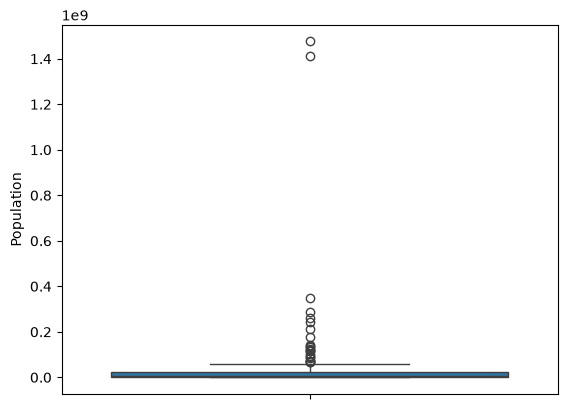

In [22]:

sns.boxplot(df["Population"])


## Keep Outliers 


For a world population dataset, countries like India and China naturally have much larger populations than others. These are real observations, not data errors.

Therefore, it's usually better to not remove them, because they are meaningful and accurately represent the real-world data.

In [23]:
df1 = pd.DataFrame(df.groupby("Country")["Population"].sum())
df1

,Population
Country,
Afghanistan,45047069
Albania,2751025
Algeria,48028334
American Samoa,45319
Andorra,83753
...,...
Wallis & Futuna,11113
Western Sahara,610813
Yemen,42961653


In [24]:
df

,Rank,Country,Population,Yearly Change (%),Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population (%),World Share (%)
0,1,India,1476625576,0.87,12760051,497,2973190,0,1.93,29.2,37.6,17.800000
1,2,China,1412914089,0.00,0,150,9388211,0,1.03,40.6,68.7,17.000000
2,3,United States,349035494,0.51,1759687,38,9147420,1177848,1.63,38.7,83.1,4.200000
3,4,Indonesia,287886782,0.76,2165546,159,1811570,0,2.08,30.7,60.3,3.500000
4,5,Pakistan,259299791,1.60,4080237,336,770880,0,3.44,20.8,34.7,3.100000
...,...,...,...,...,...,...,...,...,...,...,...,...
229,230,Montserrat,4328,0.00,0,43,100,0,1.45,41.8,11.7,0.000052
230,231,Falkland Islands,3465,0.00,0,0,12170,0,1.69,43.4,68.4,0.000042
231,232,Tokelau,2691,3.18,83,269,10,43,2.54,27.6,0.0,0.000032
232,233,Niue,1822,0.05,1,7,260,2,2.44,35.1,45.2,0.000022


In [25]:
df.to_csv("Cleaned_Data_world_population.csv", index=False)
df

,Rank,Country,Population,Yearly Change (%),Net Change,Density,Land Area,Migrants,Fertility Rate,Median Age,Urban Population (%),World Share (%)
0,1,India,1476625576,0.87,12760051,497,2973190,0,1.93,29.2,37.6,17.800000
1,2,China,1412914089,0.00,0,150,9388211,0,1.03,40.6,68.7,17.000000
2,3,United States,349035494,0.51,1759687,38,9147420,1177848,1.63,38.7,83.1,4.200000
3,4,Indonesia,287886782,0.76,2165546,159,1811570,0,2.08,30.7,60.3,3.500000
4,5,Pakistan,259299791,1.60,4080237,336,770880,0,3.44,20.8,34.7,3.100000
...,...,...,...,...,...,...,...,...,...,...,...,...
229,230,Montserrat,4328,0.00,0,43,100,0,1.45,41.8,11.7,0.000052
230,231,Falkland Islands,3465,0.00,0,0,12170,0,1.69,43.4,68.4,0.000042
231,232,Tokelau,2691,3.18,83,269,10,43,2.54,27.6,0.0,0.000032
232,233,Niue,1822,0.05,1,7,260,2,2.44,35.1,45.2,0.000022


In [26]:
df.columns


Index(['Rank', 'Country', 'Population', 'Yearly Change (%)', 'Net Change',
       'Density', 'Land Area', 'Migrants', 'Fertility Rate', 'Median Age',
       'Urban Population (%)', 'World Share (%)'],
      dtype='str')

In [27]:
df2 = pd.DataFrame(df.groupby("Country")["World Share (%)"].sum())
df2


,World Share (%)
Country,
Afghanistan,0.54000
Albania,0.03000
Algeria,0.58000
American Samoa,0.00055
Andorra,0.00100
...,...
Wallis & Futuna,0.00013
Western Sahara,0.00740
Yemen,0.52000


## Univariate Analysis

In [28]:
df["Population"].describe()

count               234.0
mean      35465139.683761
std      139474153.486104
min                 506.0
25%             438926.75
50%             5776466.5
75%           24288353.75
max          1476625576.0
Name: Population, dtype: Float64

## Bivariate Analysis

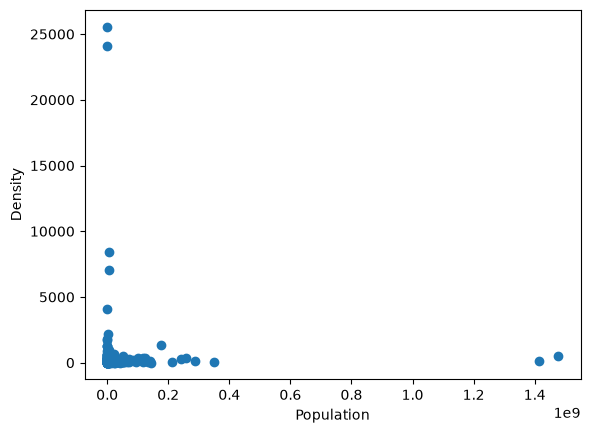

In [29]:

plt.scatter(df["Population"], df["Density"])
plt.xlabel("Population")
plt.ylabel("Density")
plt.show()

- The plot indicates a weak relationship between population and population density, with a few significant outliers

# Data Visualization

In [30]:
print(df["Population"].max())
print(df["Population"].min())

1476625576
506


## Bar Chart
- Top 10 countries by population

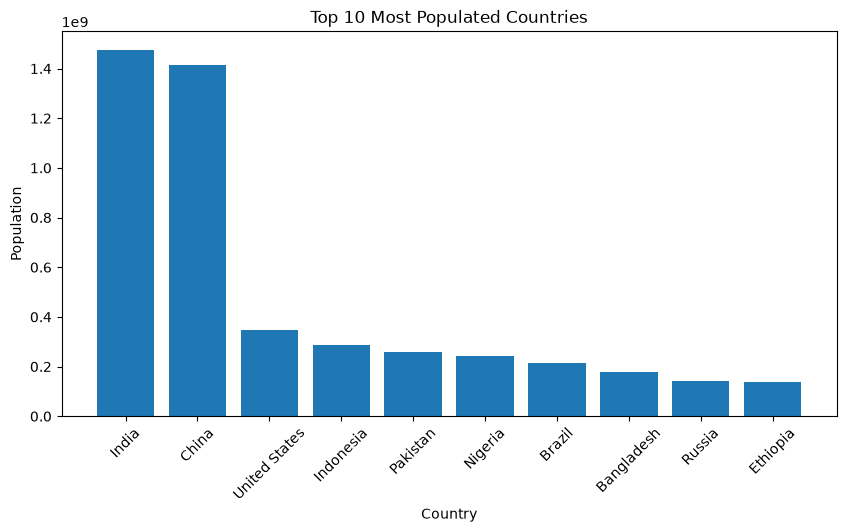

In [31]:
top10 = df.nlargest(10, "Population")

plt.figure(figsize=(10,5))
plt.bar(top10["Country"], top10["Population"])
plt.title("Top 10 Most Populated Countries")
plt.xlabel("Country")
plt.ylabel("Population")
plt.xticks(rotation=45)
plt.show()

## Histogram (Population Distribution)
- Understand how the population values are distributed.

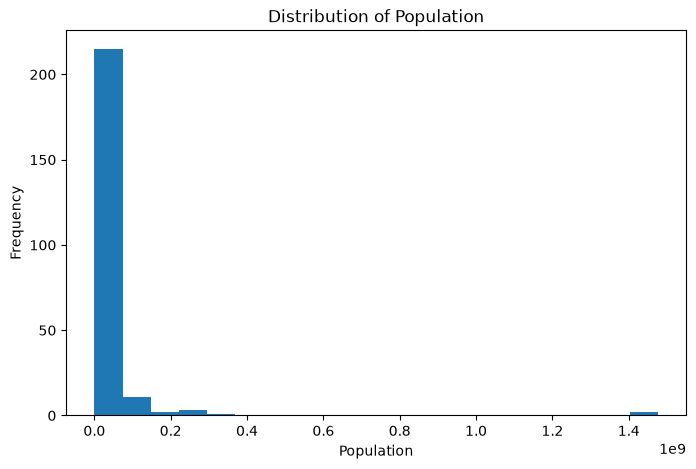

In [32]:

plt.figure(figsize=(8,5))
plt.hist(df["Population"], bins=20)
plt.title("Distribution of Population")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

- The population distribution is positively skewed, with most countries having low populations and a few outliers with very high populations.

## Scatter Plot (Population vs Fertility Rate)

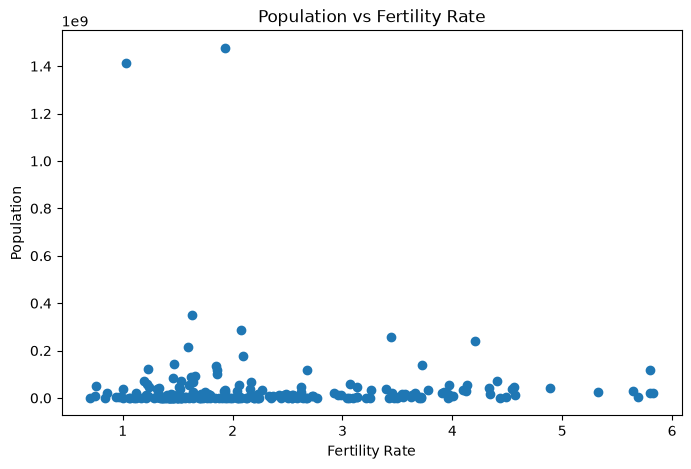

In [33]:
plt.figure(figsize=(8,5))
plt.scatter(df["Fertility Rate"], df["Population"])
plt.title("Population vs Fertility Rate")
plt.xlabel("Fertility Rate")
plt.ylabel("Population")
plt.show()

- The plot indicates no strong correlation between fertility rate and population, as countries with varying fertility rates have widely different population sizes

## Horizontal Bar Chart (Top 10 Highest Density)

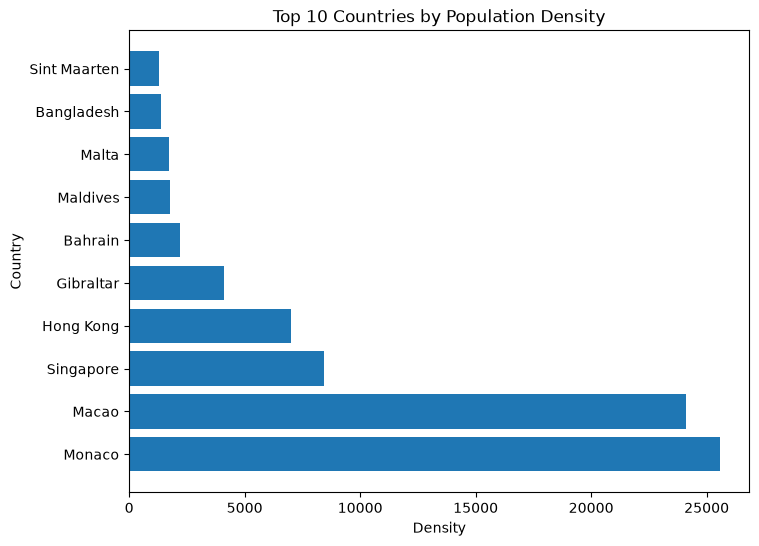

In [34]:
top10_density = df.nlargest(10, "Density")

plt.figure(figsize=(8,6))
plt.barh(top10_density["Country"], top10_density["Density"])
plt.title("Top 10 Countries by Population Density")
plt.xlabel("Density")
plt.ylabel("Country")
plt.show()

## Pie Chart (Top 5 Population Share)

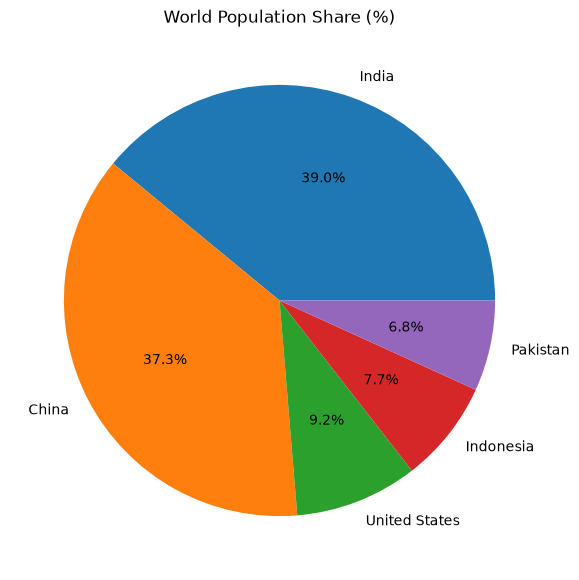

In [35]:
top5 = df.nlargest(5, "Population")

plt.figure(figsize=(7,7))
plt.pie(top5["World Share (%)"],
        labels=top5["Country"],
        autopct="%1.1f%%")

plt.title("World Population Share (%)")
plt.show()

# Insights

## Largest population

In [36]:
df.loc[df["Population"].idxmax()]

Rank                             1
Country                      India
Population              1476625576
Yearly Change (%)             0.87
Net Change                12760051
Density                        497
Land Area                  2973190
Migrants                         0
Fertility Rate                1.93
Median Age                    29.2
Urban Population (%)          37.6
World Share (%)               17.8
Name: 0, dtype: object

## Smallest population

In [37]:
df.loc[df["Population"].idxmin()]

Rank                         234
Country                 Holy See
Population                   506
Yearly Change (%)            1.0
Net Change                     5
Density                     1265
Land Area                      0
Migrants                      13
Fertility Rate               1.0
Median Age                  56.2
Urban Population (%)         0.0
World Share (%)         0.000006
Name: 233, dtype: object

## Highest density 

In [38]:
df.loc[df["Density"].idxmax()]

Rank                        216
Country                  Monaco
Population                38087
Yearly Change (%)           0.0
Net Change                    0
Density                   25562
Land Area                     1
Migrants                    106
Fertility Rate             2.08
Median Age                 53.1
Urban Population (%)        0.0
World Share (%)         0.00046
Name: 215, dtype: object

## Lowest fertility rate

In [39]:
df.loc[df["Fertility Rate"].idxmin()]

Rank                       167
Country                  Macao
Population              723188
Yearly Change (%)         0.16
Net Change                1181
Density                  24106
Land Area                   30
Migrants                   826
Fertility Rate             0.7
Median Age                40.3
Urban Population (%)      98.3
World Share (%)         0.0087
Name: 166, dtype: object

## Highest world share

In [40]:
df.loc[df["World Share (%)"].idxmax()]

Rank                             1
Country                      India
Population              1476625576
Yearly Change (%)             0.87
Net Change                12760051
Density                        497
Land Area                  2973190
Migrants                         0
Fertility Rate                1.93
Median Age                    29.2
Urban Population (%)          37.6
World Share (%)               17.8
Name: 0, dtype: object

- India is the most populated country in the dataset.
- China is the second most populated country.
- Population distribution is highly right-skewed.
- India and China appear as outliers in the population box plot, but they represent valid real-world values.
- A small number of countries account for a large share of the world's population.
- Population density varies significantly across countries.

# Conclusion

This project successfully demonstrates the complete data analysis pipeline, beginning with web scraping and ending with meaningful visualizations and insights.

Using Python libraries such as Requests, BeautifulSoup, Pandas, Matplotlib, and Seaborn, the raw population data was transformed into a clean and structured dataset suitable for analysis.

The exploratory data analysis revealed significant patterns in global population distribution, highlighted genuine outliers such as India and China, and demonstrated relationships among demographic variables through statistical analysis and visualizations.

Overall, this project showcases practical applications of web scraping, data preprocessing, exploratory data analysis, and data visualization using Python.